# 01 GBDT training

# 02 CV result

In [5]:
# 我已经有很多cv的结果了
# 200row 100column结果 -> R²
# 20个随机数。然后去看这个随机结果是什么？
import os
import pandas as pd
work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
folder = os.path.join(work_folder, r'16_6387_GBDT_hr_2016_cv_results.xlsx')
file = pd.read_excel(folder)
file

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,param_subsample,...,split93_test_score,split94_test_score,split95_test_score,split96_test_score,split97_test_score,split98_test_score,split99_test_score,mean_test_score,std_test_score,rank_test_score
0,75.811172,63.756662,0.107415,0.119423,0.034310,10,0.825518,2,4168,0.899332,...,0.901533,0.890866,0.911724,0.896975,0.903246,0.893036,0.866596,0.893874,0.014852,153
1,13.059228,14.271990,0.020635,0.033087,0.160941,8,0.710264,2,4168,0.725724,...,0.901439,0.886276,0.908546,0.886311,0.885778,0.897446,0.868310,0.891677,0.015263,164
2,8.121032,8.910455,0.034728,0.065140,0.202677,13,0.493413,2,4168,0.742276,...,0.875051,0.887577,0.894577,0.893222,0.871674,0.892271,0.839738,0.878045,0.016784,188
3,9.428400,10.155298,0.025746,0.049743,0.134202,13,0.563208,2,4168,0.890301,...,0.889637,0.889041,0.906039,0.890239,0.896779,0.892963,0.864942,0.886148,0.016252,173
4,37.142518,37.338834,0.174345,0.195607,0.011479,9,0.346747,2,4168,0.888872,...,0.903451,0.907251,0.917078,0.902709,0.905254,0.902936,0.874696,0.899568,0.014354,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,11.792527,13.109565,0.018610,0.032408,0.314812,5,0.896473,2,4168,0.754653,...,0.881850,0.888031,0.907063,0.886752,0.898942,0.878337,0.849989,0.883506,0.016445,179
196,33.621891,34.071841,0.103519,0.125653,0.009478,7,0.576278,2,4168,0.716646,...,0.911907,0.909809,0.923447,0.908473,0.916359,0.910985,0.883369,0.907486,0.014018,30
197,7.366595,8.030015,0.017817,0.037059,0.255663,12,0.844769,2,4168,0.698602,...,0.877384,0.866662,0.885987,0.882241,0.887809,0.883236,0.837030,0.876038,0.017204,191
198,34.921532,31.918235,0.097310,0.115142,0.002014,7,0.519894,2,4168,0.899675,...,0.905654,0.906962,0.919558,0.905333,0.908840,0.906952,0.878867,0.903556,0.014307,63


In [ ]:
# import os
# import pandas as pd
# import numpy as np
# from collections import Counter

# work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
# name = r"GBDT_hr_2016_cv_results.xlsx"
# results = []  # 存储所有文件的结果

# # 遍历文件夹找目标文件
# for file in os.listdir(work_folder):
#     if file.endswith(name):
#         folder = os.path.join(work_folder, file)

#         # 读入
#         df = pd.read_excel(folder)

#         # 找最大值对应的行
#         best_row = df.loc[df['mean_test_score'].idxmax()]

#         prefix = file.split("_GBDT")[0]  # 截取前缀，比如 "15_3184"
#         seed_num = int(prefix.split("_")[0])  # 提取前缀里的第一个数字部分

#         # 把结果存入列表
#         results.append({
#             "Seed": seed_num,
#             "文件前缀": prefix,
#             "最优分数": best_row['mean_test_score'],
#             "learning_rate": float(best_row['param_learning_rate']),
#             "subsample": float(best_row['param_subsample']),
#             "max_depth": int(best_row['param_max_depth']),
#             "max_features": float(best_row['param_max_features'])
#         })

# # 转成 DataFrame
# results_df = pd.DataFrame(results)

# # 按 Seed 排序
# results_df = results_df.sort_values(by="Seed").reset_index(drop=True)

# # print("==== 所有结果表格 ====")
# print(results_df)

# # 每个参数的唯一值统计
# print("\n==== 每个参数的唯一值统计 ====")
# for col in ["learning_rate", "subsample", "max_depth", "max_features"]:
#     counts = results_df[col].value_counts()
#     print(f"\n参数 {col}:")
#     print(counts)

# print("\n==== 每个参数的最高频取值 ====")
# top_values = {}
# for col in ["learning_rate", "subsample", "max_depth", "max_features"]:
#     counts = results_df[col].value_counts()
#     top_val = counts.idxmax()   # 出现次数最多的取值
#     top_count = counts.max()    # 出现次数
#     print(f"参数 {col}: 最常见值 = {top_val}, 出现次数 = {top_count}")
#     top_values[col] = (top_val, top_count)
# print(top_values)

# # 先把最高频参数提取出来
# best_params = {
#     "param_learning_rate": top_values["learning_rate"][0],
#     "param_subsample": top_values["subsample"][0],
#     "param_max_depth": top_values["max_depth"][0],
#     "param_max_features": top_values["max_features"][0],
# }

# print("\n==== 使用最高频参数组合查找对应的CV结果 ====")
# print(best_params)
# scores = []  # 保存 (文件前缀, 分数)

# for file in os.listdir(work_folder):
#     if file.endswith(name):
#         folder = os.path.join(work_folder, file)
#         df = pd.read_excel(folder)

#         # 筛选符合最高频参数组合的行
#         mask = (
#             (df["param_learning_rate"] == best_params["param_learning_rate"]) &
#             (df["param_subsample"] == best_params["param_subsample"]) &
#             (df["param_max_depth"] == best_params["param_max_depth"]) &
#             (df["param_max_features"] == best_params["param_max_features"])
#         )
#         match = df.loc[mask]

#         if not match.empty:
#             mean_score = match["mean_test_score"].values[0]
#             prefix = file.split("_GBDT")[0]
#             scores.append((prefix, mean_score))
#             print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

# # 计算平均值
# if scores:
#     all_scores = [s[1] for s in scores]
#     avg_score = sum(all_scores) / len(all_scores)
#     print(f"\n平均 mean_test_score = {avg_score}")

#     # 找最接近平均值的那个
#     closest = min(scores, key=lambda x: abs(x[1] - avg_score))
#     print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")


    Seed     文件前缀      最优分数  learning_rate  subsample  max_depth  max_features
0      0   0_9394  0.914752       0.011021   0.565109          5      0.836007
1      1    1_898  0.914906       0.011021   0.565109          5      0.836007
2      2   2_2398  0.918615       0.013651   0.563425          5      0.602176
3      3   3_5906  0.918484       0.019596   0.557018          5      0.711836
4      4   4_2343  0.916721       0.013651   0.563425          5      0.602176
5      5   5_8225  0.912296       0.011021   0.565109          5      0.836007
6      6   6_5506  0.917759       0.013651   0.563425          5      0.602176
7      7   7_6451  0.915307       0.013651   0.563425          5      0.602176
8      8   8_2670  0.915465       0.011021   0.565109          5      0.836007
9      9   9_3497  0.916365       0.011021   0.565109          5      0.836007
10    10  10_1087  0.917739       0.011021   0.565109          5      0.836007
11    11  11_1819  0.915541       0.013651   0.56342

# 1

In [8]:
import os
import pandas as pd

work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
name = r"GBDT_hr_2016_cv_results.xlsx"
results = []  

# 遍历文件夹找目标文件
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)
        best_row = df.loc[df['mean_test_score'].idxmax()]
        prefix = file.split("_GBDT")[0]
        seed_num = int(prefix.split("_")[0])  

        results.append({
            "Seed": seed_num,
            "prefix": prefix,
            "mean_test_score": best_row['mean_test_score'],
            "learning_rate": float(best_row['param_learning_rate']),
            "subsample": float(best_row['param_subsample']),
            "max_depth": int(best_row['param_max_depth']),
            "max_features": float(best_row['param_max_features'],)
        })

# 转成 DataFrame
results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)
print(results_df)
results_df.to_excel(os.path.join(work_folder, 'cv_pairs.xlsx'), index=False)

# === 统计完整组合出现次数 ===
combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
    .value_counts().reset_index(name="count")
print(combo_counts)

# 取出现次数最多的组合
best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
print("\n==== 出现最多的参数组合 ====")
print(best_combo)

# === 用这个组合查找对应的 mean_test_score ===
scores = []
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)
        mask = (
            (df["param_learning_rate"] == best_combo["learning_rate"]) &
            (df["param_subsample"] == best_combo["subsample"]) &
            (df["param_max_depth"] == best_combo["max_depth"]) &
            (df["param_max_features"] == best_combo["max_features"])
        )
        match = df.loc[mask]
        if not match.empty:
            mean_score = match["mean_test_score"].values[0]
            prefix = file.split("_GBDT")[0]
            scores.append((prefix, mean_score))
            print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

# 平均值 + 最接近的结果
if scores:
    all_scores = [s[1] for s in scores]
    avg_score = sum(all_scores) / len(all_scores)
    print(f"\n平均 mean_test_score = {avg_score}")
    closest = min(scores, key=lambda x: abs(x[1] - avg_score))
    print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")


    Seed   prefix  mean_test_score  learning_rate  subsample  max_depth  \
0      0   0_9394         0.914752       0.011021   0.565109          5   
1      1    1_898         0.914906       0.011021   0.565109          5   
2      2   2_2398         0.918615       0.013651   0.563425          5   
3      3   3_5906         0.918484       0.019596   0.557018          5   
4      4   4_2343         0.916721       0.013651   0.563425          5   
5      5   5_8225         0.912296       0.011021   0.565109          5   
6      6   6_5506         0.917759       0.013651   0.563425          5   
7      7   7_6451         0.915307       0.013651   0.563425          5   
8      8   8_2670         0.915465       0.011021   0.565109          5   
9      9   9_3497         0.916365       0.011021   0.565109          5   
10    10  10_1087         0.917739       0.011021   0.565109          5   
11    11  11_1819         0.915541       0.013651   0.563425          5   
12    12  12_2308        

# 2

In [159]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial
import os
import pandas as pd



grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
target = 'hr_2016'
print(best_combo)
# 已经固定的最佳参数
best_params = {
    'learning_rate':  best_combo["learning_rate"],
    'max_depth': int(best_combo["max_depth"]),
    'n_estimators': 4168,
    'subsample': best_combo["subsample"],
    'min_samples_split': 2,
    'max_features': best_combo["max_features"],
}
print({k: type(v) for k, v in best_params.items()})

np.random.seed(0)  # 固定种子以便复现
random_seeds = np.random.choice(10000, size=20, replace=False)

years = [2016]
for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

X = gdf_clean[explanatory_vars_gbdt]
y = gdf_clean[target]
# 假设你已有 X, y（特征和目标），只是要划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seeds[9]
)
print(random_seeds[9])
# 定义并训练模型
model = GradientBoostingRegressor(**best_params, random_state=0)
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算指标
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

# 打印结果
print("==== Final Model Performance ====")
print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
# 特征重要性
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": explanatory_vars_gbdt,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n==== Feature Importances ====")
print(feature_importance)

# # 可视化
# plt.figure(figsize=(8, 5))
# plt.barh(feature_importance["Feature"], feature_importance["Importance"])
# plt.gca().invert_yaxis()  # 让最重要的排在最上面
# plt.xlabel("Importance")
# plt.title("Feature Importances (GBDT)")
# plt.tight_layout()
# plt.show()

{'learning_rate': 0.01102140393287835, 'subsample': 0.5651090922378933, 'max_depth': 5.0, 'max_features': 0.8360070757116593}
{'learning_rate': <class 'float'>, 'max_depth': <class 'int'>, 'n_estimators': <class 'int'>, 'subsample': <class 'float'>, 'min_samples_split': <class 'int'>, 'max_features': <class 'float'>}
3497
==== Final Model Performance ====
Train R²: 0.9994, RMSE: 0.0422
Test  R²: 0.9253, RMSE: 0.4928

==== Feature Importances ====
   Feature  Importance
0      BCR    0.447111
3     NDVI    0.152739
10       Y    0.090826
1      BHV    0.079528
5       WR    0.063781
9        X    0.041905
6   Dist_W    0.030974
4       EV    0.029060
2      SVF    0.027650
8   Dist_M    0.019639
7   Dist_P    0.016787


c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# 1 + 2 predict models 

In [161]:
# 简化后的找参数 01
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial

all_results = []  # 存所有结果

target_ranges = ['nor_2016','ext_2016','hr_2016']
for target in target_ranges:

    work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
    name = rf"GBDT_{target}_cv_results.xlsx"
    results = []  

    # 遍历文件夹找目标文件
    for file in os.listdir(work_folder):
        if file.endswith(name):
            folder = os.path.join(work_folder, file)
            df = pd.read_excel(folder)
            best_row = df.loc[df['mean_test_score'].idxmax()]
            prefix = file.split("_GBDT")[0]
            seed_num = int(prefix.split("_")[0])  

            results.append({
                "Seed": seed_num,
                "文件前缀": prefix,
                "最优分数": best_row['mean_test_score'],
                "learning_rate": float(best_row['param_learning_rate']),
                "subsample": float(best_row['param_subsample']),
                "max_depth": int(best_row['param_max_depth']),
                "max_features": float(best_row['param_max_features'])
            })

    # 转成 DataFrame
    results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)

    # === 统计完整组合出现次数 ===
    combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
        .value_counts().reset_index(name="count")
    print(combo_counts)

    # 取出现次数最多的组合
    best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
    print("\n==== 出现最多的参数组合 ====")
    print(best_combo)

    # === 用这个组合查找对应的 mean_test_score ===
    scores = []
    for file in os.listdir(work_folder):
        if file.endswith(name):
            folder = os.path.join(work_folder, file)
            df = pd.read_excel(folder)
            mask = (
                (df["param_learning_rate"] == best_combo["learning_rate"]) &
                (df["param_subsample"] == best_combo["subsample"]) &
                (df["param_max_depth"] == best_combo["max_depth"]) &
                (df["param_max_features"] == best_combo["max_features"])
            )
            match = df.loc[mask]
            if not match.empty:
                mean_score = match["mean_test_score"].values[0]
                prefix = file.split("_GBDT")[0]
                scores.append((prefix, mean_score))
                print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

    # 平均值 + 最接近的结果
    if scores:
        all_scores = [s[1] for s in scores]
        avg_score = sum(all_scores) / len(all_scores)
        print(f"\n平均 mean_test_score = {avg_score}")
        closest = min(scores, key=lambda x: abs(x[1] - avg_score))
        print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")
        seed_idx, seed_value = closest[0].split("_")
        seed_idx = int(seed_idx)
        print(f"最接近平均值的文件前缀：{closest[0]} "
            f"(第 {seed_idx} 个 random seed, 值={seed_value}), "
            f"mean_test_score = {closest[1]}")

    ######################################################################
    grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
    explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究

    print(best_combo)
    # 已经固定的最佳参数
    best_params = {
        'learning_rate':  best_combo["learning_rate"],
        'max_depth': int(best_combo["max_depth"]),
        'n_estimators': 4168,
        'subsample': best_combo["subsample"],
        'min_samples_split': 2,
        'max_features': best_combo["max_features"],
    }
    # print({k: type(v) for k, v in best_params.items()})

    np.random.seed(0)  # 固定种子以便复现
    random_seeds = np.random.choice(10000, size=20, replace=False)

    years = [2016]
    for year in years:
        # 清理后的网格数据
        file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    X = gdf_clean[explanatory_vars_gbdt]
    y = gdf_clean[target]
    # 假设你已有 X, y（特征和目标），只是要划分
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seeds[seed_idx]
    )
    print(random_seeds[9])
    # 定义并训练模型
    model = GradientBoostingRegressor(**best_params, random_state=0)
    model.fit(X_train, y_train)

    # 预测
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 计算指标
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
    test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

    # 打印结果
    print("==== Final Model Performance ====")
    print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    # 特征重要性
    importances = model.feature_importances_
    feature_importance = pd.DataFrame({
        "Feature": explanatory_vars_gbdt,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\n==== Feature Importances ====")
    print(feature_importance)

    # # 可视化
    # plt.figure(figsize=(8, 5))
    # plt.barh(feature_importance["Feature"], feature_importance["Importance"])
    # plt.gca().invert_yaxis()  # 让最重要的排在最上面
    # plt.xlabel("Importance")
    # plt.title(f"{target} Feature Importances (GBDT)")
    # plt.tight_layout()
    # plt.show()

    ###########################################################################

    # Feature importance 
    importances = model.feature_importances_
    feature_importance = pd.DataFrame({
        "Feature": explanatory_vars_gbdt,
        "FeatureImportance_TrainModel": importances
    })

    # 拼接额外信息
    feature_importance["GridSize"] = 480
    feature_importance["Target"] = target
    feature_importance["Random seed"] = random_seeds[seed_idx]
    feature_importance["Train_R2"] = train_r2
    feature_importance["Train_RMSE"] = train_rmse
    feature_importance["Test_R2"] = test_r2
    feature_importance["Test_RMSE"] = test_rmse
    feature_importance["learning_rate"] = best_params["learning_rate"]
    feature_importance["max_depth"] = best_params["max_depth"]
    feature_importance["max_features"] = best_params["max_features"]
    feature_importance["min_samples_split"] = best_params["min_samples_split"]
    feature_importance["n_estimators"] = best_params["n_estimators"]
    feature_importance["subsample"] = best_params["subsample"]
    feature_importance["CV_mean_test_score "] = avg_score

    # 存入总列表
    all_results.append(feature_importance)

# 合并所有 target 的结果
final_df = pd.concat(all_results, ignore_index=True)

# 打印预览
print(final_df.head())

# 保存到 Excel
final_df.to_excel(r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_summary_results.xlsx", index=False)

   learning_rate  subsample  max_depth  max_features  count
0       0.013651   0.563425          5      0.602176     20

==== 出现最多的参数组合 ====
{'learning_rate': 0.0136505925090242, 'subsample': 0.5634248804179491, 'max_depth': 5.0, 'max_features': 0.6021762684622403}
文件前缀：0_9394, mean_test_score = 0.9206258884211889
文件前缀：10_1087, mean_test_score = 0.9207890630433994
文件前缀：11_1819, mean_test_score = 0.9189680765029862
文件前缀：12_2308, mean_test_score = 0.9265491231731785
文件前缀：13_6084, mean_test_score = 0.9162900161040518
文件前缀：14_3724, mean_test_score = 0.9180319870973522
文件前缀：15_3184, mean_test_score = 0.9200275643594082
文件前缀：16_6387, mean_test_score = 0.9180880798678325
文件前缀：17_3728, mean_test_score = 0.9199742707159965
文件前缀：18_2702, mean_test_score = 0.9209419174504384
文件前缀：19_7883, mean_test_score = 0.921920552334514
文件前缀：1_898, mean_test_score = 0.9209281882715543
文件前缀：2_2398, mean_test_score = 0.9200878924842101
文件前缀：3_5906, mean_test_score = 0.9180863643324828
文件前缀：4_2343, mean_test_sco

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


==== Final Model Performance ====
Train R²: 0.9997, RMSE: 0.0439
Test  R²: 0.9237, RMSE: 0.6969

==== Feature Importances ====
   Feature  Importance
0      BCR    0.262765
3     NDVI    0.252275
5       WR    0.127736
4       EV    0.102801
2      SVF    0.057759
1      BHV    0.045498
9        X    0.035770
8   Dist_M    0.034620
6   Dist_W    0.031706
10       Y    0.026400
7   Dist_P    0.022670
   learning_rate  subsample  max_depth  max_features  count
0       0.013651   0.563425          5      0.602176     20

==== 出现最多的参数组合 ====
{'learning_rate': 0.0136505925090242, 'subsample': 0.5634248804179491, 'max_depth': 5.0, 'max_features': 0.6021762684622403}
文件前缀：0_9394, mean_test_score = 0.9486139473126189
文件前缀：10_1087, mean_test_score = 0.9490290521412226
文件前缀：11_1819, mean_test_score = 0.9473135961269996
文件前缀：12_2308, mean_test_score = 0.9527174169979921
文件前缀：13_6084, mean_test_score = 0.9464109697739229
文件前缀：14_3724, mean_test_score = 0.9472953860992247
文件前缀：15_3184, mean_test_sc

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


==== Final Model Performance ====
Train R²: 0.9998, RMSE: 0.0563
Test  R²: 0.9538, RMSE: 0.8294

==== Feature Importances ====
   Feature  Importance
0      BCR    0.339154
3     NDVI    0.201131
1      BHV    0.133441
5       WR    0.100933
4       EV    0.074634
2      SVF    0.041990
6   Dist_W    0.035836
10       Y    0.025307
8   Dist_M    0.018709
9        X    0.017587
7   Dist_P    0.011277
   learning_rate  subsample  max_depth  max_features  count
0       0.011021   0.565109          5      0.836007     11
1       0.013651   0.563425          5      0.602176      8
2       0.019596   0.557018          5      0.711836      1

==== 出现最多的参数组合 ====
{'learning_rate': 0.01102140393287835, 'subsample': 0.5651090922378933, 'max_depth': 5.0, 'max_features': 0.8360070757116593}
文件前缀：0_9394, mean_test_score = 0.9147522903014067
文件前缀：10_1087, mean_test_score = 0.9177390863334338
文件前缀：11_1819, mean_test_score = 0.9151008911254996
文件前缀：12_2308, mean_test_score = 0.9191270028293715
文件前缀：13

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# feature importance 出图

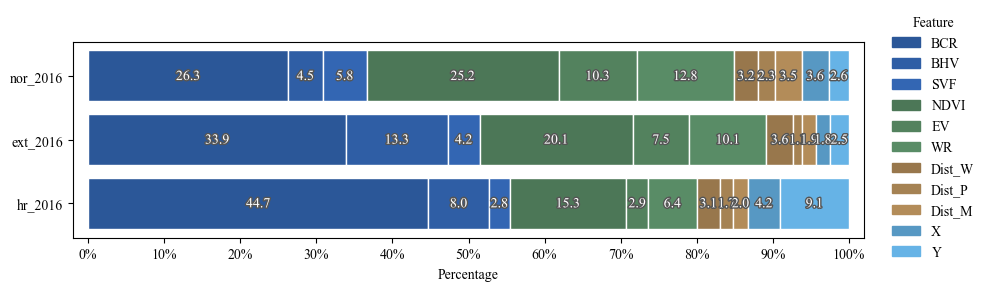

Saved to: D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_feature_importance_stacked.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
path = r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_summary_results.xlsx"
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)

# 归一化（每个 target 的行和为 1）
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

# 手动调整 Target 的行顺序
row_order = ['hr_2016', 'ext_2016','nor_2016']
pivot_norm = pivot_norm.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot_norm))))
bottom = np.zeros(len(pivot_norm))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot_norm[feature].values
    ax.barh(pivot_norm.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")
# ax.set_ylabel("Target")
# ax.set_title("Feature importance proportions per Target")

plt.tight_layout()
# 保存到本地（示例）
out_file = r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_feature_importance_stacked.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

# 3 GBDT SDEM 曲线

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions'

os.makedirs(output_fig_dir, exist_ok=True)
np.random.seed(0)  # 固定种子以便复现
random_seeds = np.random.choice(10000, size=20, replace=False)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']


years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)
    
    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    
    for target in best_df_gbdt['Target'].unique():
        
        # 取第一行参数
        row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
        params_gbdt = {
            'learning_rate':  row_gbdt["learning_rate"],
            'max_depth': row_gbdt["max_depth"],
            'n_estimators': row_gbdt["n_estimators"],
            'subsample': row_gbdt["subsample"],
            'min_samples_split': row_gbdt["min_samples_split"],
            'max_features': row_gbdt["max_features"],
            'random_state': 0
        }

        row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
        params_sdem = {
            'CONSTANT': row_sdem['CONSTANT'],
            'BCR': row_sdem['BCR'],
            'BHV': row_sdem['BHV'],
            'SVF': row_sdem['SVF'],
            'NDVI': row_sdem['NDVI'],
            'EV': row_sdem['EV'],
            'WR': row_sdem['WR'],
            'Dist_W': row_sdem['Dist_W'],
            'Dist_P': row_sdem['Dist_P'],
            'Dist_M': row_sdem['Dist_M'],
            'W_BCR': row_sdem['W_BCR'],
            'W_BHV': row_sdem['W_BHV'],
            'W_SVF': row_sdem['W_SVF'],
            'W_NDVI': row_sdem['W_NDVI'],
            'W_EV': row_sdem['W_EV'],
            'W_WR': row_sdem['W_WR'],
            'lambda': row_sdem['lambda']
        }

        # 训练 GBDT
        X = gdf_clean[explanatory_vars_gbdt]
        y = gdf_clean[target]
        model = GradientBoostingRegressor(**params_gbdt)
        model.fit(X, y)
        
        # ------------------- 同一张图绘制 -------------------
        for feature in explanatory_vars:

            fig_path = os.path.join(output_dir, f'{target}_{feature}_comparison.png')
            # if os.path.exists(fig_path):
            #     continue

            n_points = 100
            X_grid = np.linspace(X[feature].min(), X[feature].max(), n_points)

            ######################## GBDT ####################################
            # 所有的variable.其他几个variables不变。2000个点。0.05->0.8 BCR. 
            X_base = pd.DataFrame(np.tile(X.mean().values, (n_points,1)), columns=explanatory_vars_gbdt)
            X_base[feature] = X_grid
            y_gbdt_pred = model.predict(X_base)
            # print(X_base)
            # print(X_base[feature])
            # print(y_gbdt_pred)
            # print(y_gbdt_pred.shape)

            ######################## SDEM ####################################
            X_mean = gdf_clean[explanatory_vars].mean().to_dict()
            w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
            w.transform = 'r'

            WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
            WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])

            # 预测结果
            y_sdem_pred = []
            for val in X_grid:          # forgrid 值在min max 范围内
                X_temp = X_mean.copy()  # 所有的features 换成mean
                X_temp[feature] = val   # 只改我的feature 变成grid值
                WX_temp = WX_mean.copy()
                if feature in explanatory_vars_clean:
                    WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                y_pred = 0
                for var, coef in params_sdem.items():
                    if var != 'lambda': 
                        y_pred += coef * all_vars.get(var, 0)
                y_sdem_pred.append(y_pred)

            y_sdem_pred = np.array(y_sdem_pred)

            # # ------------------- 绘图 -------------------
            fig = plt.subplots(figsize=(8,5))
            # GBDT 预测曲线（蓝色）
            plt.plot(X_grid, y_gbdt_pred, color='#333333', linewidth=2, label='GBDT prediction')

            # SDEM 单变量趋势（红色虚线）
            plt.plot(X_grid, y_sdem_pred, color="#0000ff", linestyle='--', linewidth=2, label='SDEM trend')
            plt.xlabel(feature)
            plt.ylabel(target)
            plt.title(f'{feature} effect on {target}')
            plt.grid(True)
            plt.legend()
            # 固定 y 轴
            if 'hr' in target:
                plt.ylim(-20, 0)
            elif 'ext' in target:
                plt.ylim(25, 55)
            else:
                plt.ylim(20, 50)
            plt.tight_layout()
            

            plt.savefig(fig_path, dpi=300)
            plt.close()
            print(f"✅ Saved {fig_path}")


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions\2016\nor_2016_BCR_comparison.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions\2016\nor_2016_BHV_comparison.png
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


...

✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions\2016\hr_2016_Dist_W_comparison.png
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions\2016\hr_2016_Dist_P_comparison.png
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


✅ Saved D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions\2016\hr_2016_Dist_M_comparison.png


# 4 prediction comparison

In [81]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)
    
    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)
    
    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # GBDT 预测
                X = gdf_clean[explanatory_vars_gbdt]
                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean().values, (100,1)), columns=explanatory_vars_gbdt)
                X_base[feature] = X_grid
                y_gbdt_pred = GradientBoostingRegressor(**params_gbdt).fit(X, gdf_clean[target]).predict(X_base)

                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda': 
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{target} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{target} SDEM')

            plt.xlabel(feature)
            plt.ylabel('LST ratio')
            plt.title(f'{feature} effect on ext + nor {year}')
            plt.grid(True)
            plt.legend()
            plt.ylim(20,55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")


['nor_2016' 'ext_2016' 'hr_2016']


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BCR_ext_nor_2016_comparison.png


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_P_ext_nor_2016_comparison.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_M_ext_nor_2016_comparison.png


# PDP

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:1289: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots()
C:\Users\owner\AppData\Local\Temp\ipykernel_7396\1954757999.py:83: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8,5))


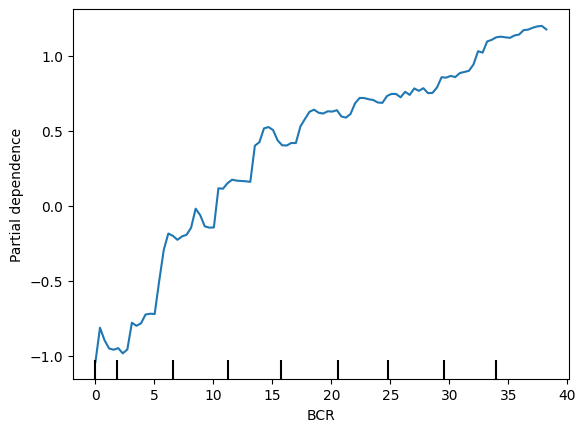

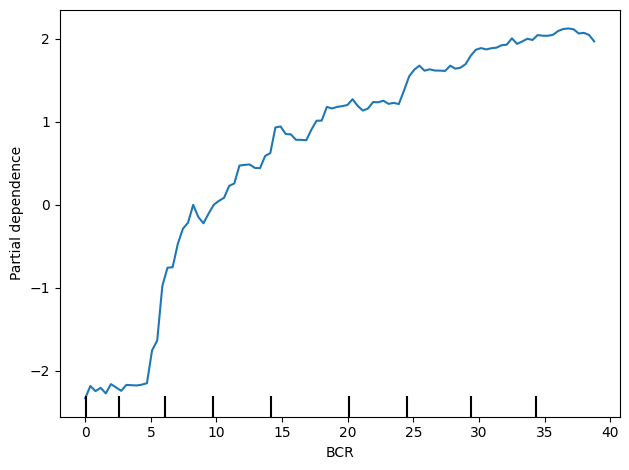

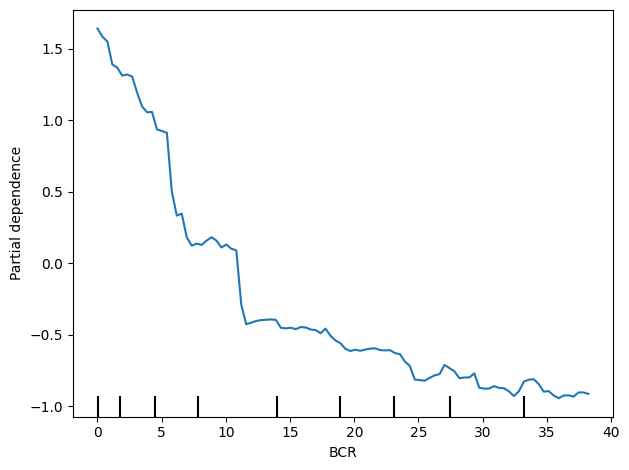

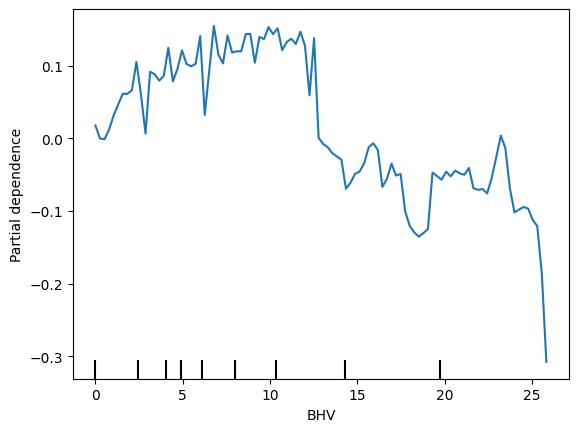

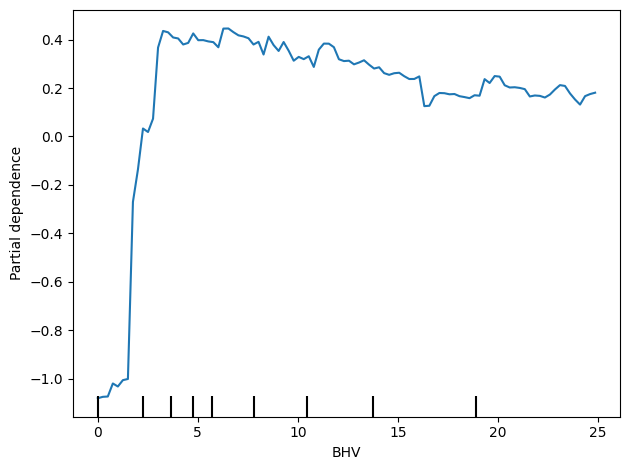

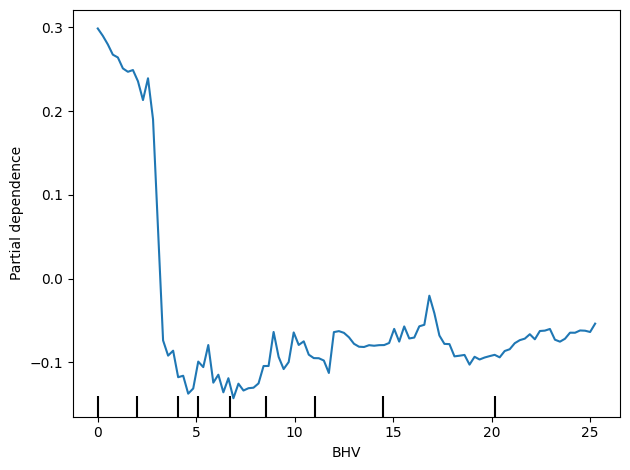

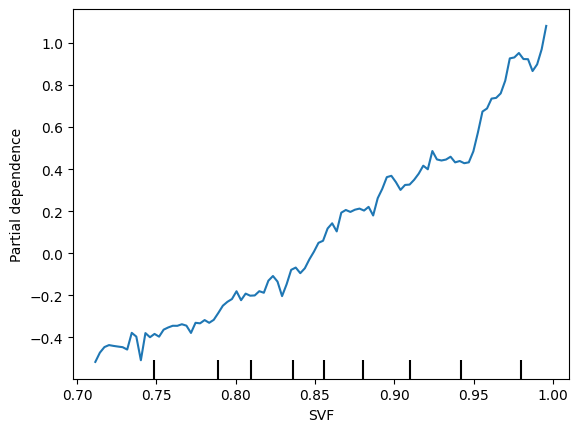

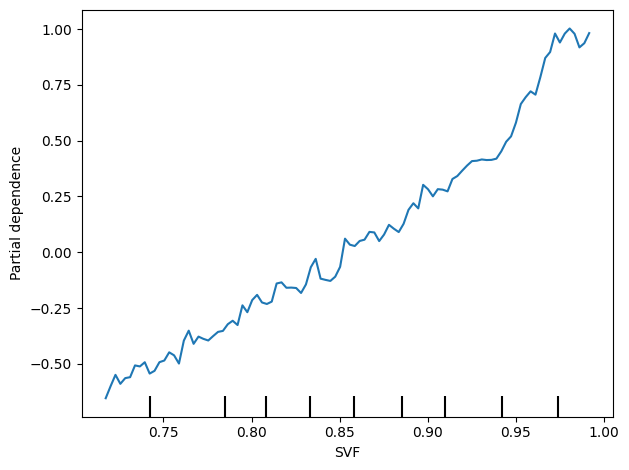

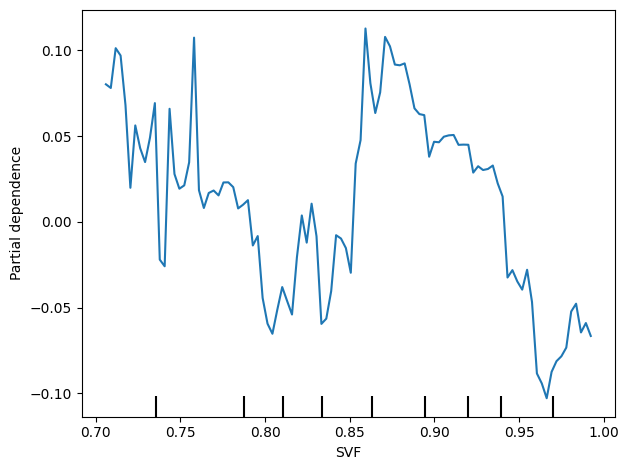

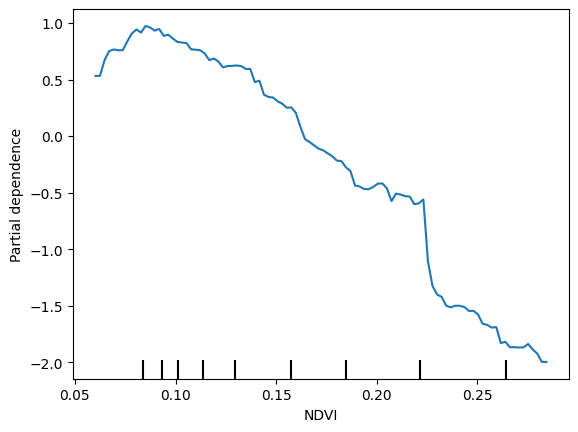

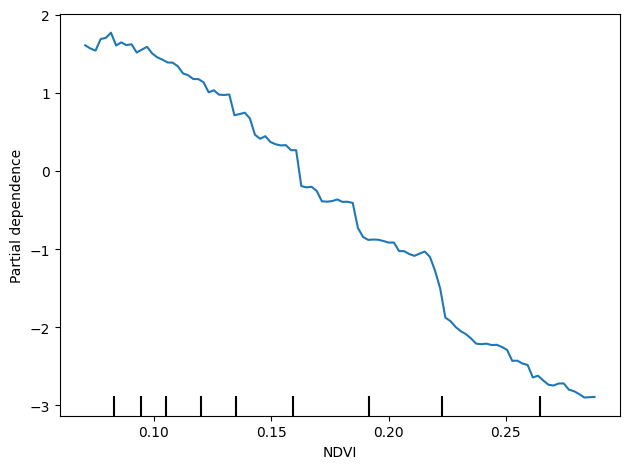

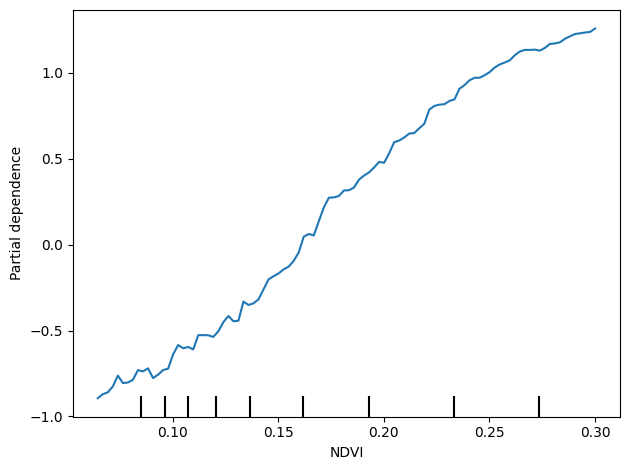

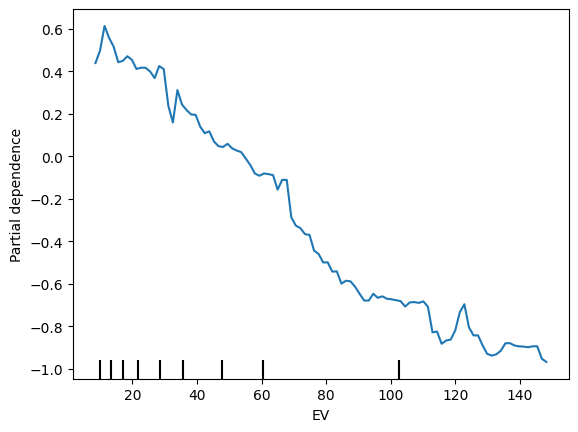

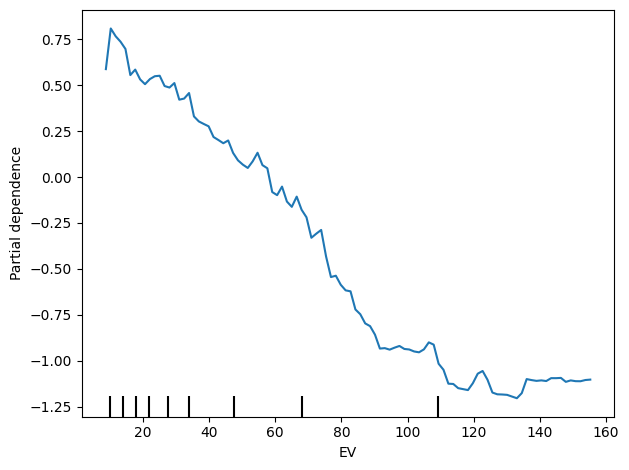

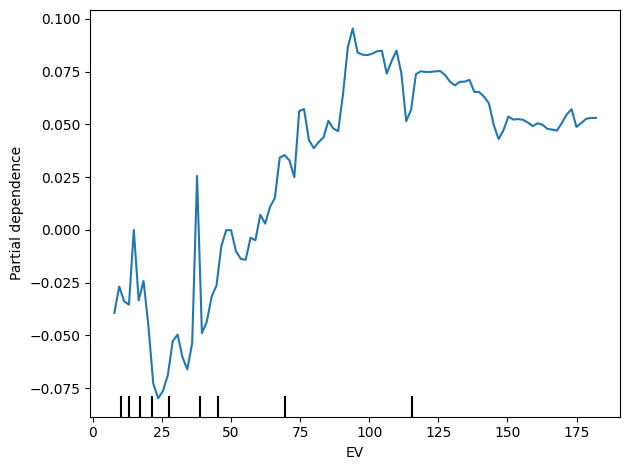

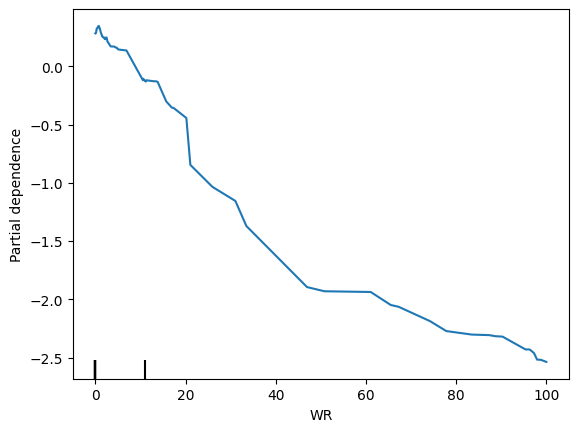

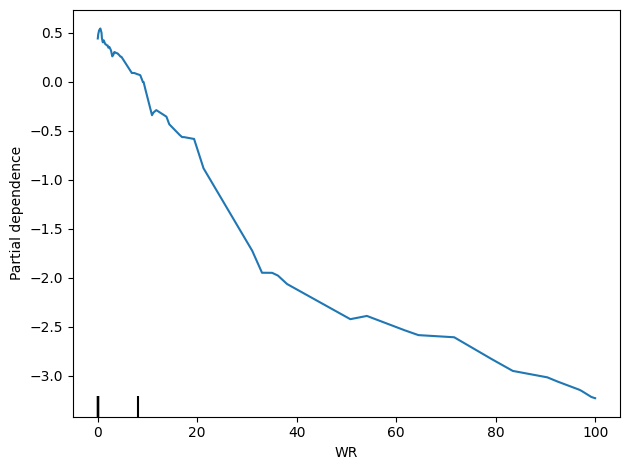

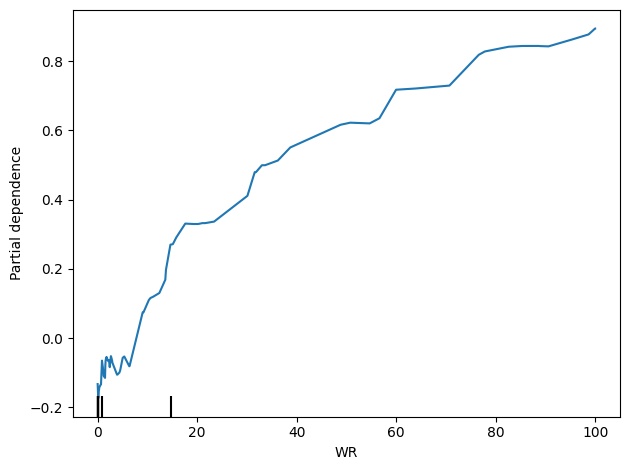

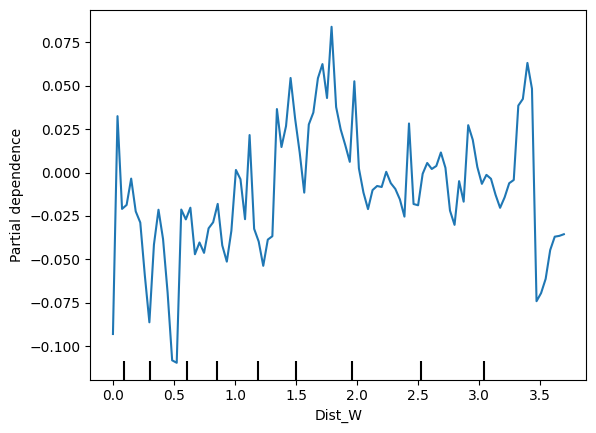

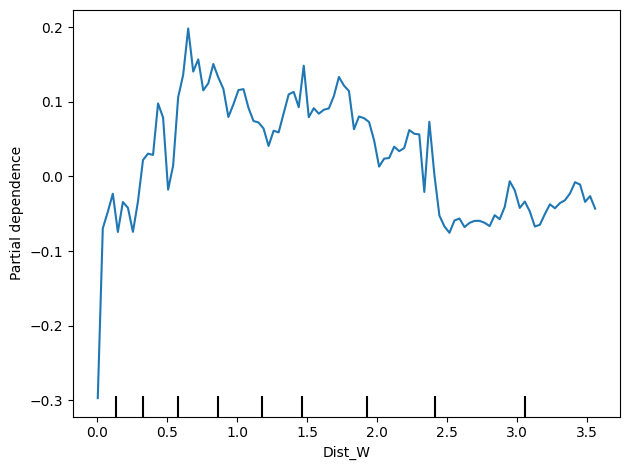

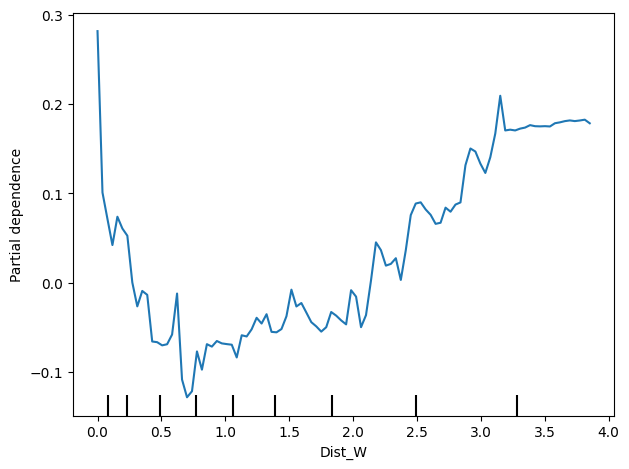

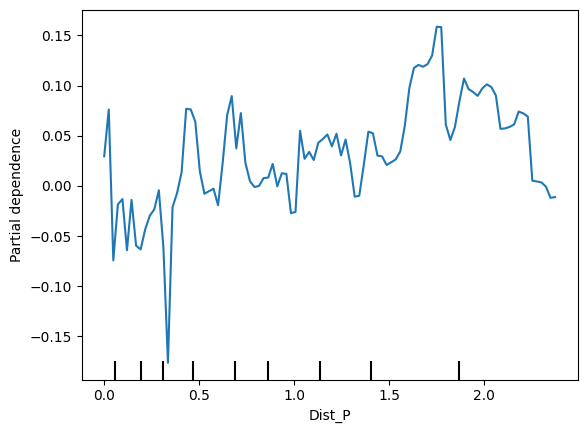

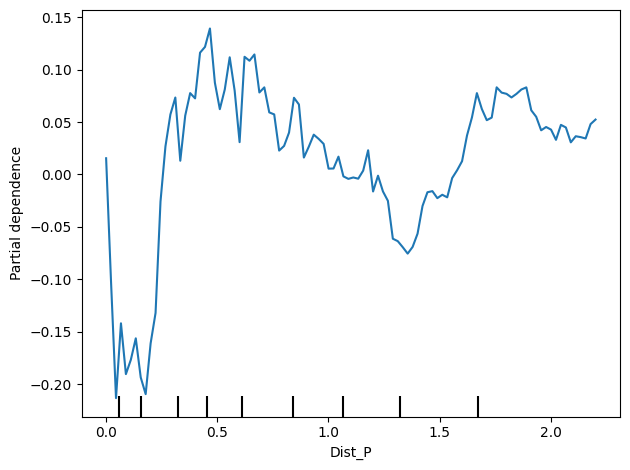

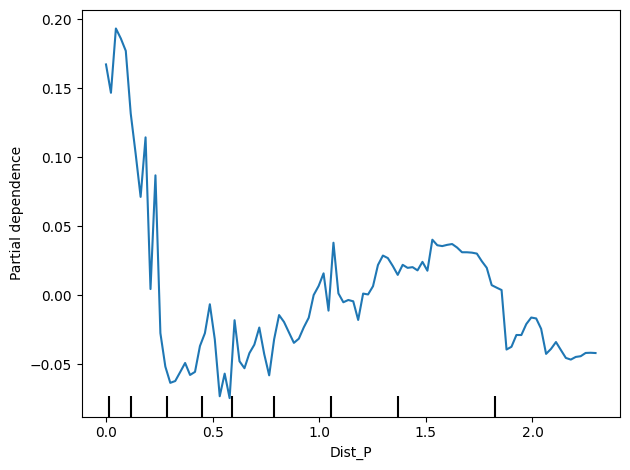

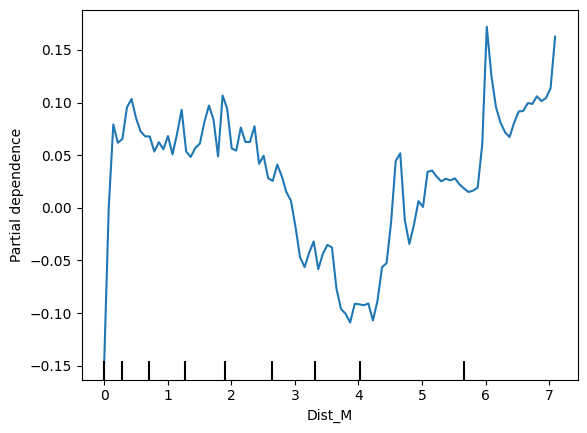

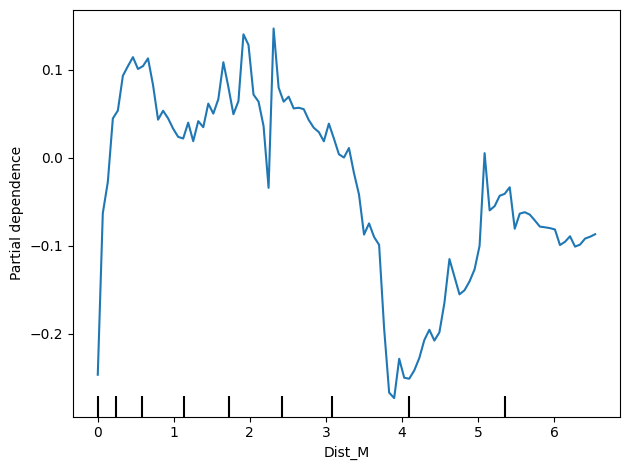

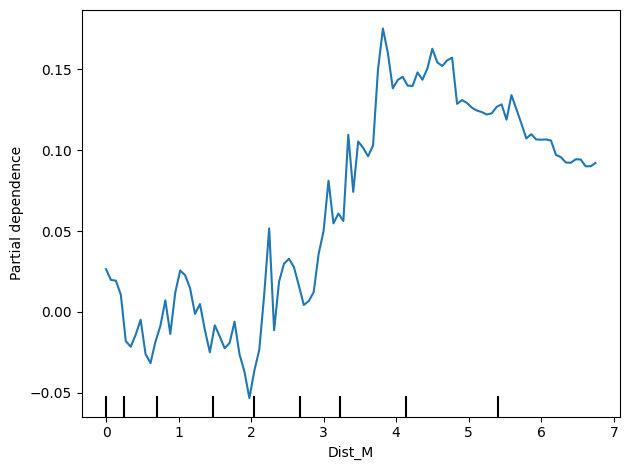

In [ ]:
from sklearn.model_selection import train_test_split
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

# ----------------- 配置 -----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = os.path.join(grid_folder, 'Machine Learning', 'figures', 'pdp_direct_plot')
os.makedirs(output_fig_dir, exist_ok=True)


explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
# explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
years = [2016]
top_n_features = 9  # PDP 提取 top N 变量

# ----------------- 主循环 -----------------
for year in years:
    file = fr'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file)
    
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)

    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)

    # --- 目标变量分组 ---
    targets = best_df_gbdt['Target'].unique()
    targets_ext_nor = [t for t in targets if ('ext' in t or 'nor' in t)]
    targets_hr = [t for t in targets if 'hr' in t]

    for feature in explanatory_vars:
        # ------- 第一张图：ext + nor -------
        fig, ax = plt.subplots(figsize=(8,5))
        colors = {
            targets_ext_nor[0]: '#000000',  # 第一个 target 用黑色
            targets_ext_nor[1]: '#0000ff'   # 第二个 target 用蓝色
        }
        for target in targets_ext_nor:
            row_gbdt = best_df_gbdt[best_df_gbdt['Target'] == target].iloc[0]
            params_gbdt = {
                'learning_rate': row_gbdt['learning_rate'],
                'max_depth': int(row_gbdt['max_depth']),
                'n_estimators': int(row_gbdt['n_estimators']),
                'subsample': row_gbdt['subsample'],
                'min_samples_split': int(row_gbdt['min_samples_split']),
                'max_features': float(row_gbdt['max_features']),
                'random_state':0
            }
            np.random.seed(0)  # 固定种子以便复现
            random_seeds = np.random.choice(10000, size=20, replace=False)

            X = gdf_clean[explanatory_vars_gbdt]
            y = gdf_clean[target]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
            model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

            disp = PartialDependenceDisplay.from_estimator(model, X_test, [feature], kind='average', ax=None)
            x_vals = disp.lines_[0][0].get_xdata()
            y_vals = disp.lines_[0][0].get_ydata()
            y_vals_actual = y_vals + y_test.mean()
            ax.plot(x_vals, y_vals_actual, linewidth=2, label=target,color=colors[target])
        
        ax.set_xlabel(feature)
        ax.set_ylabel("Temperature (°C)")
        ax.set_title(f'{feature} effect on ext + nor ({year})')
        ax.grid(True)
        ax.legend()
        ax.set_ylim(20, 55)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f'PDP_{feature}_ext_nor.jpg'), dpi=300)
        plt.close(fig)

        # ------- 第二张图：hr -------
        if targets_hr:
            fig, ax = plt.subplots(figsize=(8,5))

            for target in targets_hr:
                row_gbdt = best_df_gbdt[best_df_gbdt['Target'] == target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

                disp = PartialDependenceDisplay.from_estimator(model, X_test, [feature], kind='average', ax=None)
                x_vals = disp.lines_[0][0].get_xdata()
                y_vals = disp.lines_[0][0].get_ydata()
                y_vals_actual = y_vals + y_test.mean()

                ax.plot(x_vals, y_vals_actual, linewidth=2, label=target,color='#000000')

            ax.set_xlabel(feature)
            ax.set_ylabel("Temperature (°C)")
            ax.set_title(f'{feature} effect on hr ({year})')
            ax.grid(True)
            ax.legend()
            ax.set_ylim(-20, 0)
            plt.tight_layout()
            fig.savefig(os.path.join(output_dir, f'PDP_{feature}_hr.jpg'), dpi=300)
            plt.close(fig)

In [ ]:
from sklearn.model_selection import train_test_split
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
import numpy as np

# ----------------- 配置 -----------------
grid_folder = r'D:\seoul\grids\lst_map\lst_map\final_clean\480_based'
output_fig_dir = os.path.join(grid_folder, 'Machine Learning', 'figures', 'pdp_direct_plot')
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y']
explanatory_vars_sdem = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']

years = [2016]

# ----------------- 主循环 -----------------
for year in years:
    # 读取清理后的网格数据
    file = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取 GBDT 最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)

    # 读取 SDEM 最佳参数
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)

    targets = best_df_gbdt['Target'].unique()
    targets_ext_nor = [t for t in targets if 'ext' in t.lower() or 'nor' in t.lower()]
    targets_hr = [t for t in targets if 'hr' in t.lower()]

    for feature in explanatory_vars_sdem:
        # ------- EXT + NOR 图 -------
        fig, ax = plt.subplots(figsize=(8,5))
        colors = {targets_ext_nor[0]: '#000000', targets_ext_nor[1]: '#0000ff'}

        for target in targets_ext_nor:
            # --- GBDT PDP ---
            row_gbdt = best_df_gbdt[best_df_gbdt['Target'] == target].iloc[0]
            params_gbdt = {
                'learning_rate': row_gbdt['learning_rate'],
                'max_depth': int(row_gbdt['max_depth']),
                'n_estimators': int(row_gbdt['n_estimators']),
                'subsample': row_gbdt['subsample'],
                'min_samples_split': int(row_gbdt['min_samples_split']),
                'max_features': float(row_gbdt['max_features']),
                'random_state': 0
            }

            X = gdf_clean[explanatory_vars_gbdt]
            y = gdf_clean[target]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=row_gbdt["Random seed"])
            model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

            disp = PartialDependenceDisplay.from_estimator(model, X_test, [feature], kind='average', ax=None)
            x_vals = disp.lines_[0][0].get_xdata()
            y_vals = disp.lines_[0][0].get_ydata()
            y_vals_actual = y_vals + y_test.mean()
            ax.plot(x_vals, y_vals_actual, linewidth=2, label=f'{target} GBDT', color=colors[target])

            # --- SDEM 预测 ---
            row_sdem = best_df_sdem[best_df_sdem['Target'] == target].iloc[0]
            params_sdem = {var: row_sdem[var] for var in row_sdem.index if var not in ['Target','lambda']}
            X_mean = gdf_clean[explanatory_vars_sdem].mean().to_dict()

            X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
            y_sdem_pred = []
            for val in X_grid:
                X_temp = X_mean.copy()
                X_temp[feature] = val
                all_vars = {'CONSTANT': 1.0, **X_temp}
                y_pred = sum([coef * all_vars.get(var, 0) for var, coef in params_sdem.items()])
                y_sdem_pred.append(y_pred)
            y_sdem_pred = np.array(y_sdem_pred)

            ax.plot(X_grid, y_sdem_pred, linestyle='--', linewidth=2, label=f'{target} SDEM', color=colors[target])

        ax.set_xlabel(feature)
        ax.set_ylabel("Temperature (°C)")
        ax.set_title(f'{feature} effect on ext + nor ({year})')
        ax.grid(True)
        ax.legend()
        ax.set_ylim(20, 55)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f'PDP_{feature}_ext_nor.jpg'), dpi=300)
        plt.close(fig)

        # ------- HR 图 -------
        if targets_hr:
            fig, ax = plt.subplots(figsize=(8,5))
            for target in targets_hr:
                # GBDT
                row_gbdt = best_df_gbdt[best_df_gbdt['Target'] == target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=row_gbdt["Random seed"])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

                disp = PartialDependenceDisplay.from_estimator(model, X_test, [feature], kind='average', ax=None)
                x_vals = disp.lines_[0][0].get_xdata()
                y_vals = disp.lines_[0][0].get_ydata()
                y_vals_actual = y_vals + y_test.mean()
                ax.plot(x_vals, y_vals_actual, linewidth=2, label=f'{target} GBDT', color='#000000')

            ax.set_xlabel(feature)
            ax.set_ylabel("Temperature (°C)")
            ax.set_title(f'{feature} effect on HR ({year})')
            ax.grid(True)
            ax.legend()
            ax.set_ylim(-20, 0)
            plt.tight_layout()
            fig.savefig(os.path.join(output_dir, f'PDP_{feature}_hr.jpg'), dpi=300)
            plt.close(fig)


: 

# 出一下不同的seed的PDP 值

In [ ]:
from sklearn.model_selection import train_test_split
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

# ----------------- 配置 -----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = os.path.join(grid_folder, 'Machine Learning', 'figures', 'pdp_direct_plot')
os.makedirs(output_fig_dir, exist_ok=True)


explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
years = [2016]
top_n_features = 9  # PDP 提取 top N 变量

# ----------------- 主循环 -----------------
for year in years:
    file = fr'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file)
    
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\cv_pairs.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)

    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)

    # --- 目标变量分组 ---
    targets = 'hr_2016'

    for feature in explanatory_vars:
        # 建一张图
        fig, ax = plt.subplots(figsize=(8,5))

        for seed in range(20):
            row_gbdt = best_df_gbdt[best_df_gbdt['Seed'] == seed].iloc[0]
            params_gbdt = {
                'learning_rate': row_gbdt['learning_rate'],
                'max_depth': int(row_gbdt['max_depth']),
                'n_estimators': 4168,
                'subsample': row_gbdt['subsample'],
                'min_samples_split': 2,
                'max_features': float(row_gbdt['max_features']),
                'random_state': 0
            }

            X = gdf_clean[explanatory_vars_gbdt]
            y = gdf_clean[targets]   # 注意这里应该是 targets 而不是 target
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2,
                random_state=int(str(row_gbdt["prefix"]).split("_")[1])
            )
            model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

            disp = PartialDependenceDisplay.from_estimator(model, X_test, [feature], kind='average', ax=None)
            x_vals = disp.lines_[0][0].get_xdata()
            y_vals = disp.lines_[0][0].get_ydata()
            y_vals_actual = y_vals + y_test.mean()

            if seed == 9:
                ax.plot(x_vals, y_vals_actual, linewidth=2.5, color="red", 
                        label="The final nonlinear curve", zorder=10)
            else:
                ax.plot(x_vals, y_vals_actual, linewidth=1, color="gray", alpha=0.5, zorder=1)

        ax.set_xlabel(feature)
        ax.set_ylabel("Temperature (°C)")
        ax.set_title(f'{feature} effect on hr ({year})')
        ax.grid(True)
        ax.legend()
        ax.set_ylim(-20, 0)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f'Seed_PDP_{feature}_hr.jpg'), dpi=300)
        plt.close(fig)


c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:1289: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots()
C:\Users\owner\AppData\Local\Temp\ipykernel_48700\97721443.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8,5))


KeyboardInterrupt: 

: 

# 出一下不同的seed的预测值

In [ ]:
# ==== 最终版：20 seeds 结果输出 ====
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ---------------- 配置 ----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
work_folder = os.path.join(grid_folder, "Machine Learning")
cv_file = "cv_pairs.xlsx"   # 你的CV结果文件
output_file = os.path.join(work_folder, "final_GBDT_summary_results_20seeds.xlsx")

explanatory_vars_gbdt = ['BCR','BHV','SVF','NDVI','EV','WR','Dist_W','Dist_P','Dist_M','X','Y']
target_ranges = ['nor_2016','ext_2016','hr_2016']
years = [2016]

all_results = []  # 存所有结果

# ---------------- 主循环 ----------------
for target in target_ranges:
    print(f"\n==== Target: {target} ====")

    # 1) 收集CV结果（找最常见参数组合）
    results = []
    for file in os.listdir(work_folder):
        if file.endswith(cv_file):
            df = pd.read_excel(os.path.join(work_folder, file))
            best_row = df.loc[df['mean_test_score'].idxmax()]
            prefix = file.split("_GBDT")[0]
            seed_num = int(prefix.split("_")[0])

            results.append({
                "Seed": seed_num,
                "prefix": prefix,
                "mean_test_score": best_row['mean_test_score'],
                "learning_rate": float(best_row['param_learning_rate']),
                "subsample": float(best_row['param_subsample']),
                "max_depth": int(best_row['param_max_depth']),
                "max_features": float(best_row['param_max_features'])
            })

    results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)

    # 统计完整组合出现次数
    combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
        .value_counts().reset_index(name="count")
    print("参数组合频率：\n", combo_counts)

    # 取出现次数最多的组合
    best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
    print("最常见参数组合：", best_combo)

    # 用这个组合查找对应的 mean_test_score
    scores = []
    for file in os.listdir(work_folder):
        if file.endswith(cv_file):
            df = pd.read_excel(os.path.join(work_folder, file))
            mask = (
                (df["param_learning_rate"] == best_combo["learning_rate"]) &
                (df["param_subsample"] == best_combo["subsample"]) &
                (df["param_max_depth"] == best_combo["max_depth"]) &
                (df["param_max_features"] == best_combo["max_features"])
            )
            match = df.loc[mask]
            if not match.empty:
                mean_score = match["mean_test_score"].values[0]
                prefix = file.split("_GBDT")[0]
                scores.append((prefix, mean_score))

    avg_score = np.mean([s[1] for s in scores]) if scores else np.nan
    print(f"CV 平均 mean_test_score = {avg_score:.6f}")

    # 2) 固定参数
    best_params = {
        'learning_rate':  best_combo["learning_rate"],
        'max_depth': int(best_combo["max_depth"]),
        'n_estimators': 4168,
        'subsample': best_combo["subsample"],
        'min_samples_split': 2,
        'max_features': best_combo["max_features"],
    }

    # 3) 遍历 20 个随机种子
    np.random.seed(0)
    random_seeds = np.random.choice(10000, size=20, replace=False)

    for year in years:
        file = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    X = gdf_clean[explanatory_vars_gbdt]
    y = gdf_clean[target]

    for seed in random_seeds:
        # 划分训练测试
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

        # 训练模型
        model = GradientBoostingRegressor(**best_params, random_state=seed)
        model.fit(X_train, y_train)

        # 预测 & 指标
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

        # 特征重要性
        feature_importance = pd.DataFrame({
            "Feature": explanatory_vars_gbdt,
            "FeatureImportance_TrainModel": model.feature_importances_
        })

        # 拼接额外信息
        feature_importance["GridSize"] = 480
        feature_importance["Target"] = target
        feature_importance["Random seed"] = seed
        feature_importance["Train_R2"] = train_r2
        feature_importance["Train_RMSE"] = train_rmse
        feature_importance["Test_R2"] = test_r2
        feature_importance["Test_RMSE"] = test_rmse
        feature_importance["learning_rate"] = best_params["learning_rate"]
        feature_importance["max_depth"] = best_params["max_depth"]
        feature_importance["max_features"] = best_params["max_features"]
        feature_importance["min_samples_split"] = best_params["min_samples_split"]
        feature_importance["n_estimators"] = best_params["n_estimators"]
        feature_importance["subsample"] = best_params["subsample"]
        feature_importance["CV_mean_test_score"] = avg_score  # 这里存CV均值

        all_results.append(feature_importance)

# ---------------- 保存结果 ----------------
final_df = pd.concat(all_results, ignore_index=True)
print(final_df.head())

final_df.to_excel(output_file, index=False)
print(f"\n✅ 已保存到 {output_file}")
